In [4]:
pip install linearmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# ШАГ 0. ИМПОРТ БИБЛИОТЕК
# ─────────────────────────────────────────────────────────────────────────────
"""
Что делает блок: загружает все необходимые библиотеки.
На что смотреть: убедиться, что все импорты прошли без ошибок.
Если linearmodels не установлен — выполнить в терминале:
    pip install linearmodels
"""

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, jarque_bera

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.tsa.stattools import adfuller

from linearmodels.panel import (
    PooledOLS, PanelOLS, RandomEffects, BetweenOLS, FirstDifferenceOLS
)
from linearmodels.panel.results import PanelEffectsResults

print("✓ Все библиотеки успешно загружены")

✓ Все библиотеки успешно загружены


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# ШАГ 1. ЗАГРУЗКА ДАННЫХ
# ─────────────────────────────────────────────────────────────────────────────
"""
Что делает блок: загружает CSV-файл с панельными данными.
На что смотреть:
  • Первые строки — убедиться, что данные считались корректно.
  • Названия колонок — проверить соответствие ожидаемым.
Что отправить: вывод df.head() и df.columns.
"""

FILE_PATH = "панелька_2.csv"

df = pd.read_csv(FILE_PATH, sep=';', decimal=',', encoding='utf-8-sig')

# Если decimal=',' не сработал (числа читаются как строки) — пробуем decimal='.'
# df = pd.read_csv(FILE_PATH, sep=';', decimal='.', encoding='utf-8-sig')

print("=" * 60)
print("ПЕРВЫЕ СТРОКИ ДАТАСЕТА")
print("=" * 60)
print(df.head(10).to_string())

print("\n" + "=" * 60)
print("НАЗВАНИЯ СТОЛБЦОВ")
print("=" * 60)
print(list(df.columns))

ПЕРВЫЕ СТРОКИ ДАТАСЕТА
  Country  Year              PriceGap RES_share RES_capacity     WindSolar_share RES_generation CO2_electricity
0      AT  2005                   NaN    24.353      1118.31               2.097        40880.0           254.0
1      AT  2006                   NaN    26.276     1334.785               2.845        40660.0          253.01
2      AT  2007  0.038853846153846155    28.144      1548.85               3.279        43170.0          232.69
3      AT  2008   0.02951296296296288    28.788      1542.49               3.169        44530.0          220.41
4      AT  2009   0.03839814814814815    31.039     1553.826               3.021        47180.0          195.89
5      AT  2010   0.03625925925925924    31.205     1588.634                3.17        44990.0          226.78
6      AT  2011   0.02933703703703705    31.552      1627.97  3.3920000000000003        40910.0          238.59
7      AT  2012  0.021720370370370362    32.734     1105.461               4.078 

In [4]:

# ─────────────────────────────────────────────────────────────────────────────
# ШАГ 2. ПРОВЕРКА КОРРЕКТНОСТИ СТОЛБЦОВ
# ─────────────────────────────────────────────────────────────────────────────
"""
Что делает блок: сверяет реальные столбцы с ожидаемыми.
На что смотреть: список отсутствующих столбцов.
Примечание: Import_dependency в файле ОТСУТСТВУЕТ — исключена из анализа.
Что отправить: сообщение о найденных/отсутствующих столбцах.
"""

EXPECTED_COLS = [
    'Country', 'Year', 'PriceGap',
    'RES_share', 'RES_capacity', 'WindSolar_share',
    'RES_generation', 'CO2_electricity'
]

missing = [c for c in EXPECTED_COLS if c not in df.columns]
present = [c for c in EXPECTED_COLS if c in df.columns]

print("=" * 60)
print("ПРОВЕРКА СТОЛБЦОВ")
print("=" * 60)
print(f"Ожидаемые столбцы:   {EXPECTED_COLS}")
print(f"Реальные столбцы:    {list(df.columns)}")
print(f"Найдены:             {present}")

if missing:
    print(f"\n⚠  ОТСУТСТВУЮТ СТОЛБЦЫ: {missing}")
    print("Анализ продолжается без отсутствующих столбцов.")
else:
    print("\n✓ Все ожидаемые столбцы присутствуют.")

# Переменные для анализа (только те, что есть в файле)
DEP_VAR   = 'PriceGap'
RES_VARS  = [c for c in ['RES_share', 'RES_capacity', 'WindSolar_share',
                          'RES_generation', 'CO2_electricity'] if c in df.columns]
ALL_VARS  = [DEP_VAR] + RES_VARS

print(f"\nПеременные для модели: {ALL_VARS}")

ПРОВЕРКА СТОЛБЦОВ
Ожидаемые столбцы:   ['Country', 'Year', 'PriceGap', 'RES_share', 'RES_capacity', 'WindSolar_share', 'RES_generation', 'CO2_electricity']
Реальные столбцы:    ['Country', 'Year', 'PriceGap', 'RES_share', 'RES_capacity', 'WindSolar_share', 'RES_generation', 'CO2_electricity']
Найдены:             ['Country', 'Year', 'PriceGap', 'RES_share', 'RES_capacity', 'WindSolar_share', 'RES_generation', 'CO2_electricity']

✓ Все ожидаемые столбцы присутствуют.

Переменные для модели: ['PriceGap', 'RES_share', 'RES_capacity', 'WindSolar_share', 'RES_generation', 'CO2_electricity']


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# ШАГ 3. ПЕРВИЧНАЯ ПРОВЕРКА ДАННЫХ
# ─────────────────────────────────────────────────────────────────────────────
"""
Что делает блок: выводит базовую информацию о датасете.
На что смотреть:
  • Размер — число строк и столбцов.
  • Страны и годы — убедиться, что панель охватывает правильный период.
  • Баланс панели — одинаковое ли число наблюдений по странам.
Что отправить: всю распечатку этого шага.
"""

print("=" * 60)
print("БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)

print(f"\nРазмер датасета:     {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"Число стран:         {df['Country'].nunique()}")
print(f"Список стран:        {sorted(df['Country'].unique().tolist())}")
print(f"Период (Year):       {int(df['Year'].min())} – {int(df['Year'].max())}")
print(f"Всего наблюдений:    {len(df)}")

print("\n--- Число наблюдений по странам ---")
obs_by_country = df.groupby('Country').size().rename('N_obs')
print(obs_by_country.to_string())

n_years = df['Year'].nunique()
n_countries = df['Country'].nunique()
balanced = (obs_by_country == n_years).all()
print(f"\nЧисло уникальных лет:   {n_years}")
print(f"Ожидаемых obs/страна:   {n_years}")
print(f"Панель сбалансирована:  {'ДА ✓' if balanced else 'НЕТ — несбалансированная панель ⚠'}")

print("\n--- Типы данных ---")
print(df.dtypes.to_string())

БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ

Размер датасета:     513 строк × 8 столбцов
Число стран:         27
Список стран:        ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
Период (Year):       2005 – 2023
Всего наблюдений:    513

--- Число наблюдений по странам ---
Country
AT    19
BE    19
BG    19
CY    19
CZ    19
DE    19
DK    19
EE    19
ES    19
FI    19
FR    19
GR    19
HR    19
HU    19
IE    19
IT    19
LT    19
LU    19
LV    19
MT    19
NL    19
PL    19
PT    19
RO    19
SE    19
SI    19
SK    19

Число уникальных лет:   19
Ожидаемых obs/страна:   19
Панель сбалансирована:  ДА ✓

--- Типы данных ---
Country            object
Year                int64
PriceGap           object
RES_share          object
RES_capacity       object
WindSolar_share    object
RES_generation     object
CO2_electricity    object


In [6]:


# ─────────────────────────────────────────────────────────────────────────────
# ШАГ 4. ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ
# ─────────────────────────────────────────────────────────────────────────────
"""
Что делает блок: приводит переменные к нужным типам.
На что смотреть:
  • Новые пропуски (NaN) после pd.to_numeric — строки, которые не распознались
    как числа, станут NaN.
  • Отрицательные / нулевые значения в переменных, которые будут логарифмированы.
Что отправить: таблицу новых пропусков и предупреждения об отрицательных значениях.
"""

df['Country'] = df['Country'].astype(str).str.strip()
df['Year']    = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

nan_before = df[ALL_VARS].isnull().sum()

for col in ALL_VARS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

nan_after = df[ALL_VARS].isnull().sum()
new_nans  = nan_after - nan_before

print("=" * 60)
print("НОВЫЕ ПРОПУСКИ ПОСЛЕ pd.to_numeric")
print("=" * 60)
print(new_nans[new_nans > 0].to_string() if new_nans.any() else "Новых пропусков не появилось ✓")

# Проверка отрицательных / нулевых значений
print("\n--- Проверка нулевых и отрицательных значений ---")
LOG_CANDIDATES = ['RES_capacity', 'RES_generation', 'PriceGap']
for col in LOG_CANDIDATES:
    if col in df.columns:
        n_zero = (df[col] == 0).sum()
        n_neg  = (df[col] < 0).sum()
        print(f"  {col:25s}  нулей: {n_zero:3d}  отрицательных: {n_neg:3d}")


НОВЫЕ ПРОПУСКИ ПОСЛЕ pd.to_numeric
Новых пропусков не появилось ✓

--- Проверка нулевых и отрицательных значений ---
  RES_capacity               нулей:  64  отрицательных:   0
  RES_generation             нулей:  10  отрицательных:   0
  PriceGap                   нулей:   0  отрицательных:   0


АНАЛИЗ ПРОПУСКОВ
                 Пропуски (шт.)  Пропуски (%)
PriceGap                     55         10.72
RES_share                     0          0.00
RES_capacity                  0          0.00
WindSolar_share               0          0.00
RES_generation                0          0.00
CO2_electricity               0          0.00

Строк с хотя бы одним пропуском по переменным модели: 55
    Country  Year  PriceGap  RES_share  RES_capacity  WindSolar_share  RES_generation  CO2_electricity
0        AT  2005       NaN     24.353      1118.310            2.097         40880.0           254.00
1        AT  2006       NaN     26.276      1334.785            2.845         40660.0           253.01
19       BE  2005       NaN      2.325       294.000            0.273          2110.0           241.05
20       BE  2006       NaN      2.658       307.000            0.444          2960.0           231.58
38       BG  2005       NaN      9.173         7.000            0.000          4300.0   

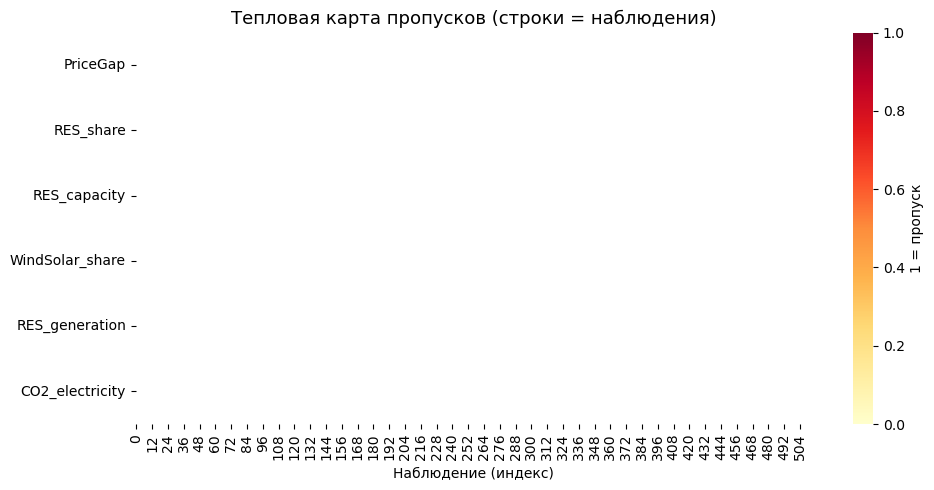

✓ missing_heatmap.png сохранён

--- Стратегия обработки пропусков ---
Пропусков > 20% нет — создаём очищенный датасет (listwise deletion).

Очищенный датасет: 458 строк (из 513 исходных, удалено 55)


In [7]:

# ─────────────────────────────────────────────────────────────────────────────
# ШАГ 5. АНАЛИЗ ПРОПУСКОВ
# ─────────────────────────────────────────────────────────────────────────────
"""
Что делает блок: исследует паттерн пропущенных значений.
На что смотреть:
  • Тепловая карта — визуальный паттерн пропусков.
  • Доля пропусков > 20% по переменной — повод рассмотреть её исключение.
  • Строки с пропусками по ключевым переменным — посмотреть, какие страны/годы.
Что отправить: таблицу пропусков + тепловую карту (missing_heatmap.png).
"""

print("=" * 60)
print("АНАЛИЗ ПРОПУСКОВ")
print("=" * 60)

miss_count = df[ALL_VARS].isnull().sum()
miss_pct   = df[ALL_VARS].isnull().mean() * 100

miss_df = pd.DataFrame({
    'Пропуски (шт.)': miss_count,
    'Пропуски (%)':   miss_pct.round(2)
})
print(miss_df.to_string())
# Строки с пропусками по ключевым переменным
rows_missing = df[df[ALL_VARS].isnull().any(axis=1)][
    ['Country', 'Year'] + ALL_VARS
]
print(f"\nСтрок с хотя бы одним пропуском по переменным модели: {len(rows_missing)}")
if len(rows_missing) > 0:
    print(rows_missing.to_string())

# Тепловая карта пропусков
fig, ax = plt.subplots(figsize=(10, max(5, len(ALL_VARS) * 0.5 + 2)))
miss_matrix = df[ALL_VARS].isnull().T.astype(int)
sns.heatmap(miss_matrix, cmap='YlOrRd', cbar_kws={'label': '1 = пропуск'},
            yticklabels=ALL_VARS, ax=ax, linewidths=0.3)
ax.set_title('Тепловая карта пропусков (строки = наблюдения)', fontsize=13)
ax.set_xlabel('Наблюдение (индекс)')
plt.tight_layout()
plt.savefig('missing_heatmap.png', dpi=150)
plt.show()
print("✓ missing_heatmap.png сохранён")

# Стратегия обработки пропусков
print("\n--- Стратегия обработки пропусков ---")
problematic = miss_df[miss_df['Пропуски (%)'] > 20].index.tolist()
if problematic:
    print(f"⚠  Переменные с долей пропусков > 20%: {problematic}")
    print("   → Рассмотреть исключение этих переменных из базовой спецификации.")
else:
    print("Пропусков > 20% нет — создаём очищенный датасет (listwise deletion).")

df_clean = df.dropna(subset=ALL_VARS + ['Country', 'Year']).copy()
print(f"\nОчищенный датасет: {len(df_clean)} строк (из {len(df)} исходных, "
      f"удалено {len(df) - len(df_clean)})")


In [8]:
 ─────────────────────────────────────────────────────────────────────────────
# ШАГ 6. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
# ─────────────────────────────────────────────────────────────────────────────
"""
Что делает блок: рассчитывает описательную статистику.вает описательную статистику.
На что смотреть:
  • Диапазон значений — нет ли аномалий (напр. отрицательный PriceGap).
  • Стандартное отклонение vs. среднее — высокая вариабельность указывает на
    неоднородность выборки.
  • Различия по странам — насколько разнятся средние по группам.
Что отправить: таблицы descriptive_stats.csv и descriptive_by_country.csv.
"""

print("=" * 60)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА (очищенный датасет)")
print("=" * 60)

desc_all = df_clean[ALL_VARS].describe().T
desc_all.columns = ['N', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
print(desc_all.round(3).to_string())

# По странам
print("\n--- Средние значения по странам ---")
desc_country = df_clean.groupby('Country')[ALL_VARS].mean().round(3)
print(desc_country.to_string())

# По годам
print("\n--- Средние значения по годам ---")
desc_year = df_clean.groupby('Year')[ALL_VARS].mean().round(3)
print(desc_year.to_string())

# Сохранение
desc_all.round(3).to_csv('descriptive_stats.csv', encoding='utf-8-sig')
desc_country.to_csv('descriptive_by_country.csv', encoding='utf-8-sig')
desc_year.to_csv('descriptive_by_year.csv', encoding='utf-8-sig')
print("\n✓ Описательная статистика сохранена в CSV")

SyntaxError: invalid character '─' (U+2500) (851661895.py, line 1)

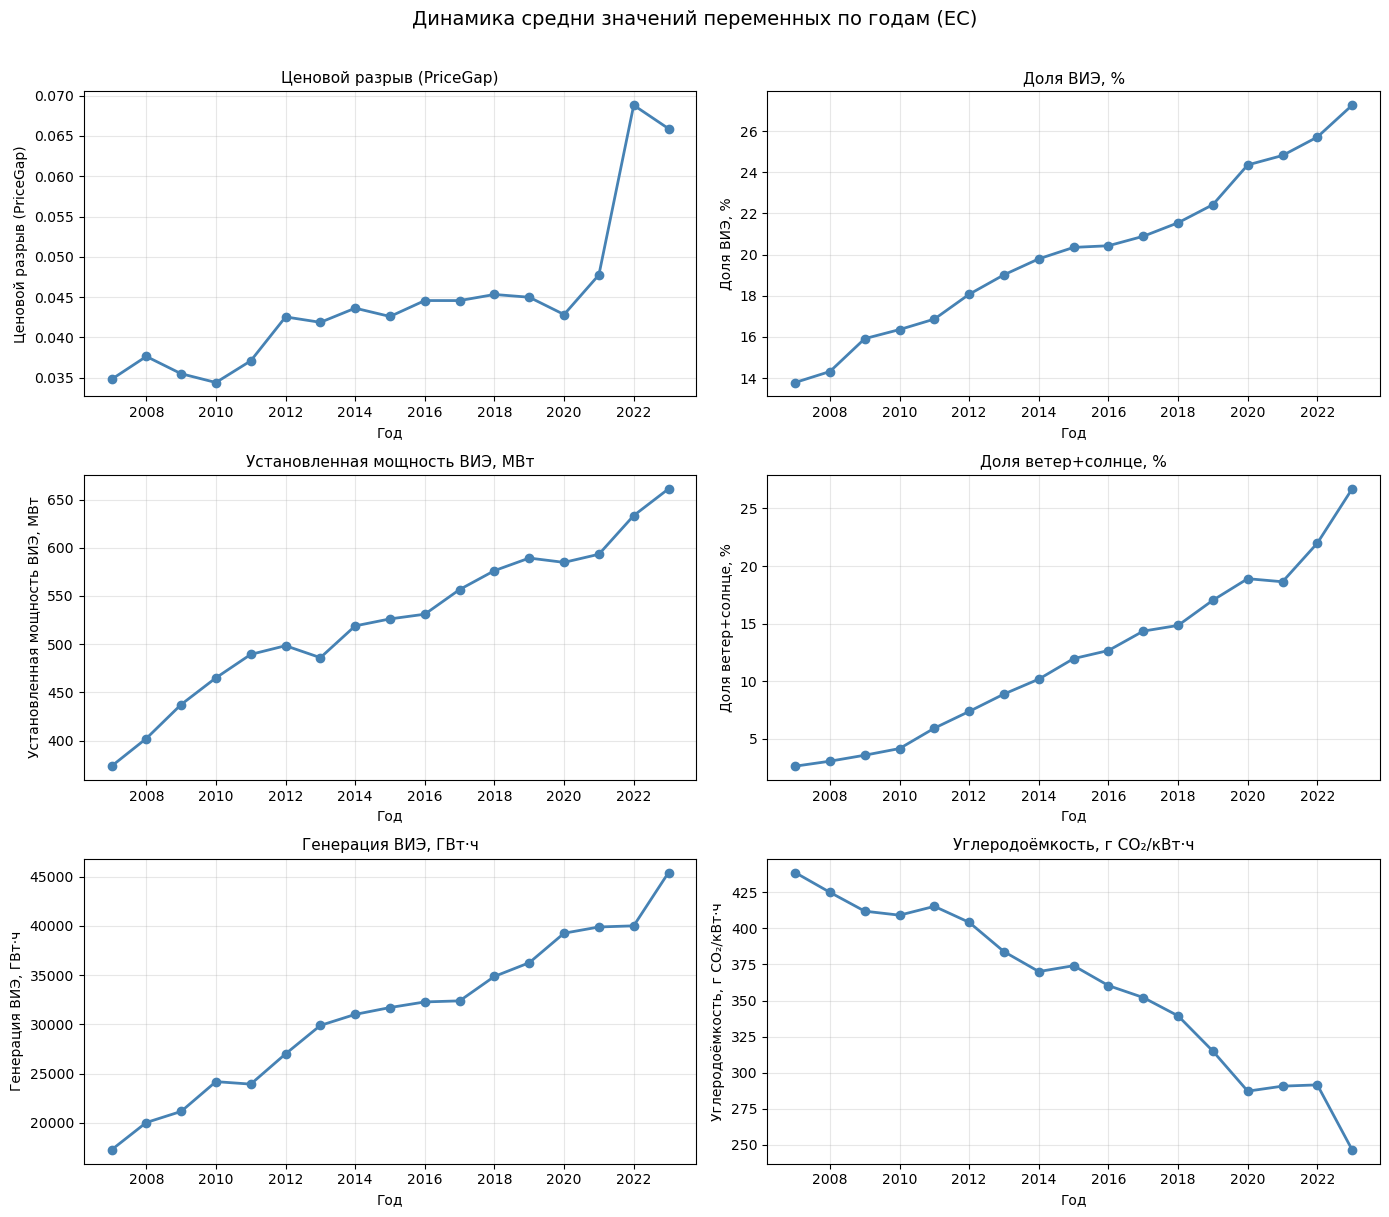

✓ trends_over_time.png сохранён


In [9]:
# ШАГ 7. ГРАФИКИ — ДИНАМИКА ПЕРЕМЕННЫХ ПО ГОДАМ
# ─────────────────────────────────────────────────────────────────────────────
"""
Что делает блок: строит графики средних значений каждой переменной по годам.
На что смотреть:
  • Тренд PriceGap — снижается ли со временем (→ интеграция растёт)?
  • Тренд RES_share / WindSolar_share / RES_generation — рост ВИЭ.
  • CO2_electricity — ожидается снижение по мере роста ВИЭ.
Что отправить: файл trends_over_time.png.
"""

vars_to_plot = ALL_VARS
labels = {
    'PriceGap':        'Ценовой разрыв (PriceGap)',
    'RES_share':       'Доля ВИЭ, %',
'RES_capacity':    'Установленная мощность ВИЭ, МВт',
    'WindSolar_share': 'Доля ветер+солнце, %',
    'RES_generation':  'Генерация ВИЭ, ГВт·ч',
    'CO2_electricity': 'Углеродоёмкость, г CO₂/кВт·ч',
}

n_plots  = len(vars_to_plot)
n_cols   = 2
n_rows   = (n_plots + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    yearly = df_clean.groupby('Year')[var].mean()
    axes[i].plot(yearly.index, yearly.values, marker='o', linewidth=2,
                 color='steelblue')
    axes[i].set_title(labels.get(var, var), fontsize=11)
    axes[i].set_xlabel('Год')
    axes[i].set_ylabel(labels.get(var, var))
    axes[i].grid(alpha=0.3)
    axes[i].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Убрать лишние оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Динамика средни значений переменных по годам (ЕС)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('trends_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ trends_over_time.png сохранён")

In [10]:
#8
  • Направление тренда — отрицательный наклон подтверждает гипотезу.
  • Нелинейности или выбросы, которые нужно учесть в модели.
Что отправить: файл scatter_plots.png.
"""

n_scatter = len(RES_VARS)
n_cols_s  = 2
n_rows_s  = (n_scatter + 1) // 2

fig, axes = plt.subplots(n_rows_s, n_cols_s, figsize=(14, 5 * n_rows_s))
axes = axes.flatten()

for i, var in enumerate(RES_VARS):
    tmp = df_clean[[DEP_VAR, var]].dropna()
    x, y = tmp[var].values, tmp[DEP_VAR].values
    axes[i].scatter(x, y, alpha=0.4, s=25, color='steelblue')

    # Линия тренда
    if len(x) > 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        xs = np.linspace(x.min(), x.max(), 200)
        axes[i].plot(xs, p(xs), color='crimson', linewidth=2, label=f'slope={z[0]:.3f}')
        axes[i].legend(fontsize=9)

    axes[i].set_xlabel(labels.get(var, var), fontsize=10)
    axes[i].set_ylabel('PriceGap', fontsize=10)
    axes[i].set_title(f'PriceGap vs. {var}', fontsize=11)
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Диаграммы рассеяния: PriceGap vs. ВИЭ-переменные', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ scatter_plots.png сохранён")



IndentationError: unexpected indent (4058032680.py, line 2)

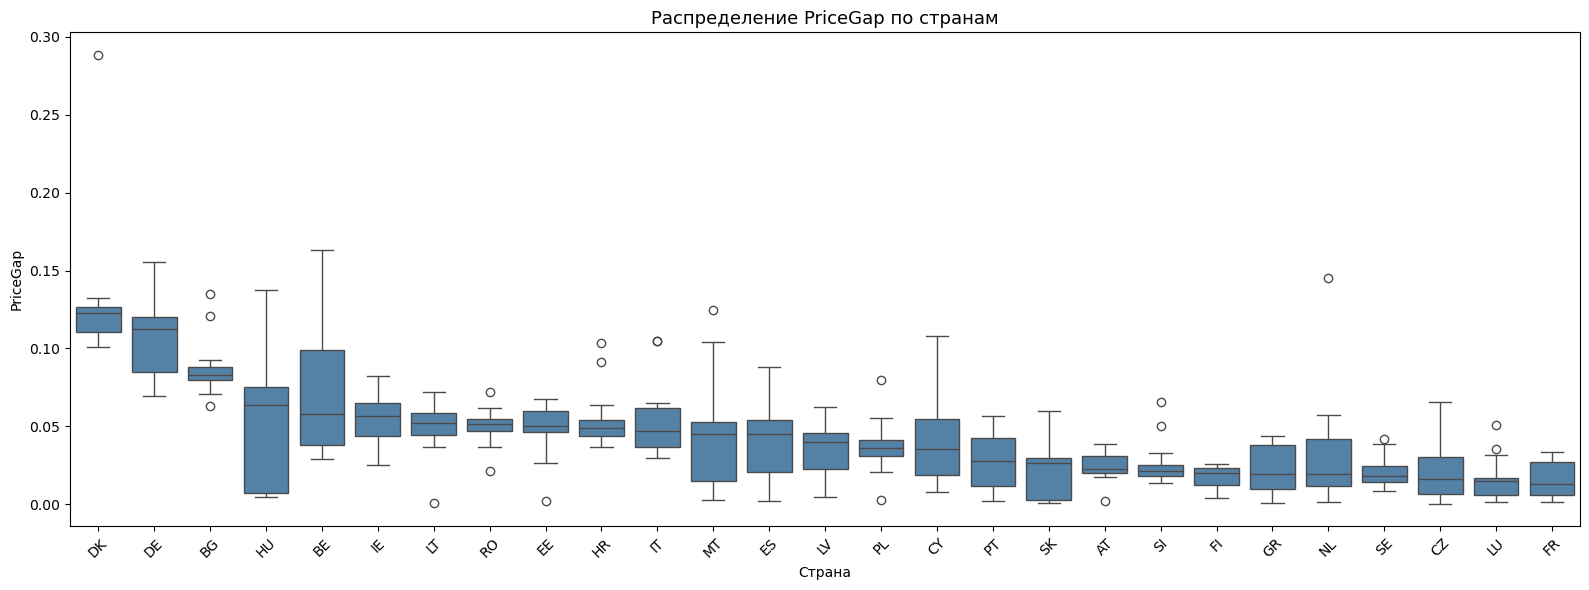

✓ boxplot_country.png сохранён


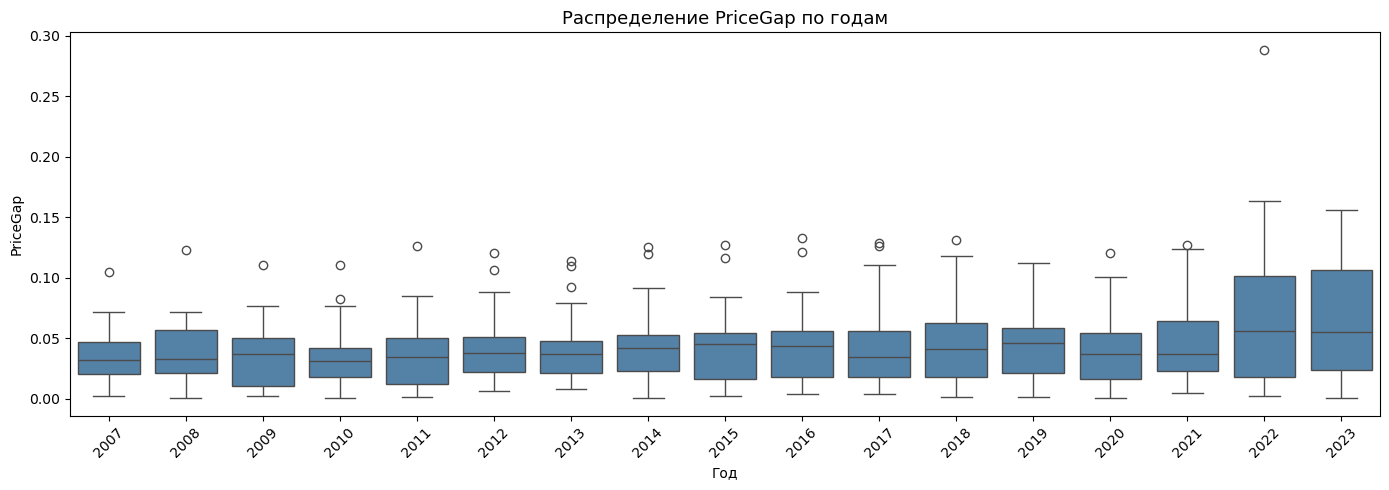

✓ boxplot_year.png сохранён


In [11]:
#9

# По странам
# По странам (seaborn поддерживает сортировку через order=)
country_order = (df_clean.groupby('Country')[DEP_VAR]
                 .median().sort_values(ascending=False).index.tolist())
fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=df_clean, x='Country', y=DEP_VAR, order=country_order,
            color='steelblue', ax=ax)
ax.set_title('Распределение PriceGap по странам', fontsize=13)
ax.set_xlabel('Страна')
ax.set_ylabel('PriceGap')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('boxplot_country.png', dpi=150)
plt.show()
print("✓ boxplot_country.png сохранён")

# По годам
year_order = sorted(df_clean['Year'].unique().tolist())
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df_clean, x='Year', y=DEP_VAR, order=year_order,
            color='steelblue', ax=ax)
ax.set_title('Распределение PriceGap по годам', fontsize=13)
ax.set_xlabel('Год')
ax.set_ylabel('PriceGap')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('boxplot_year.png', dpi=150)
plt.show()
print("✓ boxplot_year.png сохранён")

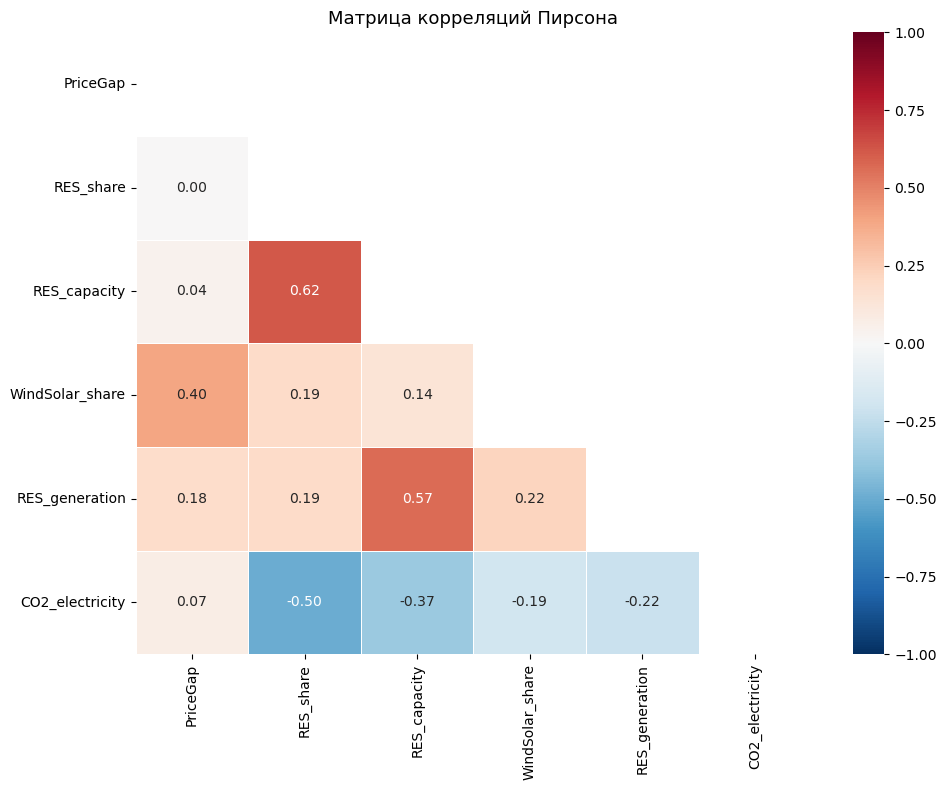

✓ correlation_matrix.png сохранён

--- Корреляция с PriceGap ---
RES_share          0.003
RES_capacity       0.043
CO2_electricity    0.074
RES_generation     0.180
WindSolar_share    0.398

✓ Высокой попарной корреляции (|r|>0.85) не обнаружено.


In [12]:
#10

corr = df_clean[ALL_VARS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Матрица корреляций Пирсона', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()
print("✓ correlation_matrix.png сохранён")

corr.round(3).to_csv('correlation_matrix.csv', encoding='utf-8-sig')

print("\n--- Корреляция с PriceGap ---")
print(corr[DEP_VAR].drop(DEP_VAR).sort_values().round(3).to_string())

# Предупреждение о мультиколлинеарности
high_corr_pairs = []
for c1 in RES_VARS:
    for c2 in RES_VARS:
        if c1 < c2 and abs(corr.loc[c1, c2]) > 0.85:
            high_corr_pairs.append((c1, c2, round(corr.loc[c1, c2], 3)))
if high_corr_pairs:
    print(f"\n⚠  Высокая попарная корреляция (|r|>0.85): {high_corr_pairs}")
    print("   → Включать эти переменные одновременно в одну регрессию рискованно.")
else:
    print("\n✓ Высокой попарной корреляции (|r|>0.85) не обнаружено.")

In [13]:
#11
print("=" * 60)
print("ТЕСТЫ НА ЕДИНИЧНЫЙ КОРЕНЬ (ADF по странам)")
print("=" * 60)

adf_results = []

for var in ALL_VARS:
    reject_count  = 0
    total_count   = 0
    for country, grp in df_clean.groupby('Country'):
        series = grp[var].dropna().values
        if len(series) < 5:
            continue
        try:
            adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC')
            reject = adf_p < 0.05
            reject_count += int(reject)
            total_count  += 1
        except Exception:
            pass
    if total_count > 0:
        share_reject = reject_count / total_count
        adf_results.append({
            'Variable':         var,
            'N_countries':      total_count,
            'N_reject_H0':      reject_count,
            'Share_reject':     round(share_reject, 3),
            'Likely_stationary': 'ДА' if share_reject >= 0.5 else 'НЕТ ⚠'
        })

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))
adf_df.to_csv('unit_root_results.csv', index=False, encoding='utf-8-sig')
print("✓ unit_root_results.csv сохранён")

ТЕСТЫ НА ЕДИНИЧНЫЙ КОРЕНЬ (ADF по странам)
       Variable  N_countries  N_reject_H0  Share_reject Likely_stationary
       PriceGap           27            6         0.222             НЕТ ⚠
      RES_share           27            4         0.148             НЕТ ⚠
   RES_capacity           25            7         0.280             НЕТ ⚠
WindSolar_share           27            2         0.074             НЕТ ⚠
 RES_generation           27            3         0.111             НЕТ ⚠
CO2_electricity           27            2         0.074             НЕТ ⚠
✓ unit_root_results.csv сохранён


In [14]:
#12
df_panel = df_clean.copy()
df_panel = df_panel.set_index(['Country', 'Year'])
df_panel.index = df_panel.index.set_levels(
    df_panel.index.levels[1].astype(int), level=1
)

print("=" * 60)
print("ПАНЕЛЬНЫЙ ДАТАСЕТ (первые строки)")
print("=" * 60)
print(df_panel.head(10).to_string())
print(f"\nФорма: {df_panel.shape}")

# Переменные для регрессий
Y = df_panel[DEP_VAR]

ПАНЕЛЬНЫЙ ДАТАСЕТ (первые строки)
              PriceGap  RES_share  RES_capacity  WindSolar_share  RES_generation  CO2_electricity
Country Year                                                                                     
AT      2007  0.038854     28.144      1548.850            3.279         43170.0           232.69
        2008  0.029513     28.788      1542.490            3.169         44530.0           220.41
        2009  0.038398     31.039      1553.826            3.021         47180.0           195.89
        2010  0.036259     31.205      1588.634            3.170         44990.0           226.78
        2011  0.029337     31.552      1627.970            3.392         40910.0           238.59
        2012  0.021720     32.734      1105.461            4.078         51330.0           185.87
        2013  0.022374     32.665      1017.352            5.856         50500.0           173.35
        2014  0.022270     33.550       958.884            7.539         50200.0    

In [15]:
#13
print("=" * 60)
print("POOLED OLS — БАЗОВАЯ СПЕЦИФИКАЦИЯ")
print("=" * 60)

SPEC_VARS = RES_VARS.copy()
X_pool    = sm.add_constant(df_panel[SPEC_VARS].dropna())
Y_pool    = Y.reindex(X_pool.index)

ols_model  = sm.OLS(Y_pool, X_pool)
ols_result = ols_model.fit(cov_type='HC1')  # робастные SE

print(ols_result.summary())

# Сохранение результатов
with open('ols_pooled_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(ols_result.summary()))
print("✓ ols_pooled_summary.txt сохранён")

POOLED OLS — БАЗОВАЯ СПЕЦИФИКАЦИЯ
                            OLS Regression Results                            
Dep. Variable:               PriceGap   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     16.47
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           6.06e-15
Time:                        21:44:30   Log-Likelihood:                 933.21
No. Observations:                 458   AIC:                            -1854.
Df Residuals:                     452   BIC:                            -1830.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const   

In [16]:
#14
print("=" * 60)
print("VIF — ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ")
print("=" * 60)

X_vif  = sm.add_constant(df_panel[SPEC_VARS].dropna()).values
vif_df = pd.DataFrame({
    'Variable': ['const'] + SPEC_VARS,
    'VIF': [variance_inflation_factor(X_vif, i)
            for i in range(X_vif.shape[1])]
})
vif_df['Проблема'] = vif_df['VIF'].apply(
    lambda v: 'Серьёзная ⚠⚠' if v > 10
    else ('Умеренная ⚠' if v > 5 else 'OK ✓')
)
print(vif_df.round(2).to_string(index=False))
vif_df.to_csv('vif_results.csv', index=False, encoding='utf-8-sig')
print("✓ vif_results.csv сохранён")

VIF — ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ
       Variable   VIF     Проблема
          const 15.36 Серьёзная ⚠⚠
      RES_share  2.07         OK ✓
   RES_capacity  2.50         OK ✓
WindSolar_share  1.10         OK ✓
 RES_generation  1.67         OK ✓
CO2_electricity  1.37         OK ✓
✓ vif_results.csv сохранён


In [17]:
#15
print("=" * 60)
print("МОДЕЛЬ С ФИКСИРОВАННЫМИ ЭФФЕКТАМИ (FE/Within)")
print("=" * 60)

X_fe = df_panel[SPEC_VARS].dropna()
Y_fe = Y.reindex(X_fe.index)

fe_model  = PanelOLS(Y_fe, X_fe, entity_effects=True, time_effects=False)
fe_result = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_result.summary)

with open('fe_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(fe_result.summary))
print("✓ fe_summary.txt сохранён")

print("\n" + "=" * 60)
print("МОДЕЛЬ СО СЛУЧАЙНЫМИ ЭФФЕКТАМИ (RE)")
print("=" * 60)

re_model  = RandomEffects(Y_fe, X_fe)
re_result = re_model.fit(cov_type='robust')
print(re_result.summary)

with open('re_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(re_result.summary))
print("✓ re_summary.txt сохранён")


# Тест Хаусмана (через сравнение коэффициентов)
print("\n--- ТЕСТ ХАУСМАНА (FE vs. RE) ---")

b_fe = fe_result.params
b_re = re_result.params

# Общие переменные
common_vars = b_fe.index.intersection(b_re.index)
b_fe_c = b_fe[common_vars]
b_re_c = b_re[common_vars]

# Ковариации
V_fe = fe_result.cov.loc[common_vars, common_vars]
V_re = re_result.cov.loc[common_vars, common_vars]

diff     = b_fe_c - b_re_c
V_diff   = V_fe - V_re

try:
    # Псевдообратная матрица для устойчивости
    V_diff_inv = np.linalg.pinv(V_diff.values)
    H_stat     = float(diff.values @ V_diff_inv @ diff.values)
    H_df       = len(common_vars)
    H_pvalue   = stats.chi2.sf(H_stat, df=H_df)

    print(f"Статистика Хаусмана χ²({H_df}) = {H_stat:.4f}")
    print(f"p-value = {H_pvalue:.4f}")
    if H_pvalue < 0.05:
        print("→ Вывод: p < 0.05 — ПРЕДПОЧТИТЕЛЬНА модель с ФИКСИРОВАННЫМИ ЭФФЕКТАМИ (FE)")
    else:
        print("→ Вывод: p ≥ 0.05 — ПРЕДПОЧТИТЕЛЬНА модель со СЛУЧАЙНЫМИ ЭФФЕКТАМИ (RE)")
except Exception as e:
    print(f"⚠  Тест Хаусмана не удалось рассчитать: {e}")

МОДЕЛЬ С ФИКСИРОВАННЫМИ ЭФФЕКТАМИ (FE/Within)
                          PanelOLS Estimation Summary                           
Dep. Variable:               PriceGap   R-squared:                        0.1140
Estimator:                   PanelOLS   R-squared (Between):             -0.4917
No. Observations:                 458   R-squared (Within):               0.1140
Date:                Wed, Apr 29 2026   R-squared (Overall):             -0.3990
Time:                        21:44:31   Log-likelihood                    1119.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.962
Entities:                          27   P-value                           0.0000
Avg Obs:                       16.963   Distribution:                   F(5,426)
Min Obs:                       16.000                                           
Max Obs:                       17.000   F-statistic (robust):  

In [18]:
#16
print("=" * 60)
print("ДВУСТОРОННЯЯ FE (entity + time effects)")
print("=" * 60)

fe2_model  = PanelOLS(Y_fe, X_fe, entity_effects=True, time_effects=True)
fe2_result = fe2_model.fit(cov_type='clustered', cluster_entity=True)
print(fe2_result.summary)

with open('twoway_fe_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(fe2_result.summary))
print("✓ twoway_fe_summary.txt сохранён")

ДВУСТОРОННЯЯ FE (entity + time effects)
                          PanelOLS Estimation Summary                           
Dep. Variable:               PriceGap   R-squared:                        0.0376
Estimator:                   PanelOLS   R-squared (Between):             -2.1453
No. Observations:                 458   R-squared (Within):              -0.0670
Date:                Wed, Apr 29 2026   R-squared (Overall):             -1.8254
Time:                        21:44:31   Log-likelihood                    1143.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.2040
Entities:                          27   P-value                           0.0075
Avg Obs:                       16.963   Distribution:                   F(5,410)
Min Obs:                       16.000                                           
Max Obs:                       17.000   F-statistic (robust):        

In [19]:
#17
print("=" * 60)
print("АЛЬТЕРНАТИВНЫЕ СПЕЦИФИКАЦИИ (FE, entity effects)")
print("=" * 60)

# Определяем спецификации в зависимости от наличия переменных
spec_definitions = {}
if all(v in df_panel.columns for v in ['RES_share', 'CO2_electricity']):
    spec_definitions['Spec1_RES_CO2'] = ['RES_share', 'CO2_electricity']
if all(v in df_panel.columns for v in ['WindSolar_share', 'RES_capacity']):
    spec_definitions['Spec2_WindSolar_Cap'] = ['WindSolar_share', 'RES_capacity']
if all(v in df_panel.columns for v in ['RES_generation', 'CO2_electricity']):
    spec_definitions['Spec3_Gen_CO2'] = ['RES_generation', 'CO2_electricity']
if all(v in df_panel.columns for v in ['RES_share', 'WindSolar_share', 'CO2_electricity']):
    spec_definitions['Spec4_Full_noCapGen'] = ['RES_share', 'WindSolar_share', 'CO2_electricity']

spec_results  = {}
spec_coef_df  = pd.DataFrame()

for spec_name, spec_vars in spec_definitions.items():
    X_spec = df_panel[spec_vars].dropna()
    Y_spec = Y.reindex(X_spec.index)

    model  = PanelOLS(Y_spec, X_spec, entity_effects=True)
    result = model.fit(cov_type='clustered', cluster_entity=True)
    spec_results[spec_name] = result

    row = {'Spec': spec_name, 'N_obs': result.nobs, 'R2_within': round(result.rsquared, 4)}
    for v in spec_vars:
        if v in result.params.index:
            row[f'{v}_coef'] = round(result.params[v], 4)
            row[f'{v}_pval'] = round(result.pvalues[v], 4)
    spec_coef_df = pd.concat([spec_coef_df, pd.DataFrame([row])], ignore_index=True)

    print(f"\n--- {spec_name}: {spec_vars} ---")
    print(result.summary)

spec_coef_df.to_csv('specifications_comparison.csv', index=False, encoding='utf-8-sig')
print("\n✓ specifications_comparison.csv сохранён")
print("\n--- СВОДНАЯ ТАБЛИЦА СПЕЦИФИКАЦИЙ ---")
print(spec_coef_df.to_string(index=False)

_IncompleteInputError: incomplete input (1032428335.py, line 41)

ДИАГНОСТИКА ОСТАТКОВ (FE-модель)


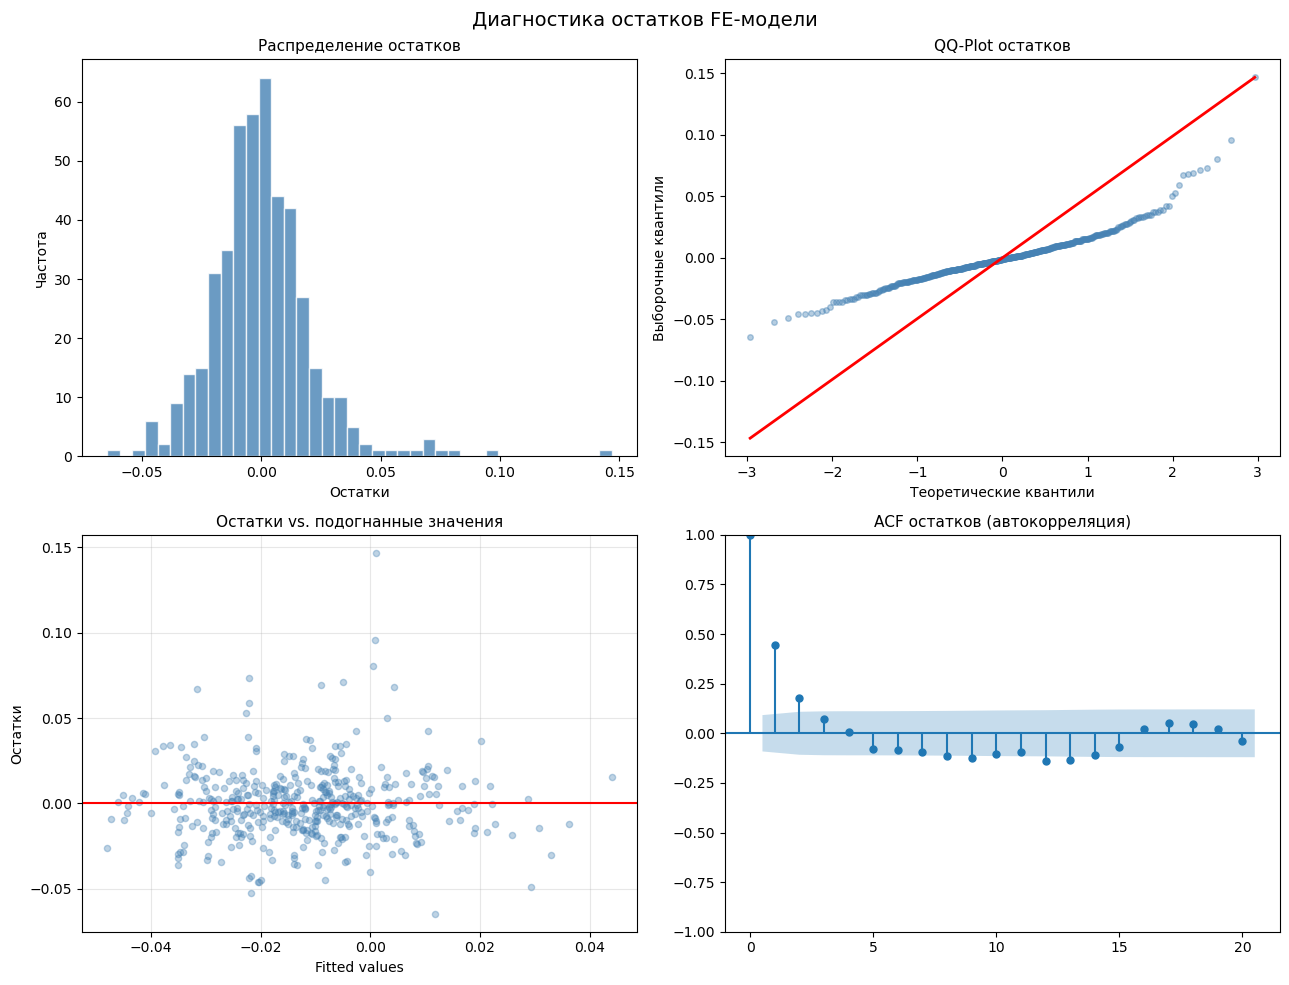

✓ residual_diagnostics.png сохранён

Тест Харке-Бера: stat=1017.400, p=0.0000
  → Остатки не нормально распределены (характерно для панельных данных)


In [24]:
#18
print("=" * 60)
print("ДИАГНОСТИКА ОСТАТКОВ (FE-модель)")
print("=" * 60)

resid   = fe_result.resids.values
fitted  = fe_result.fitted_values.values

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Histogram
axes[0, 0].hist(resid, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Распределение остатков', fontsize=11)
axes[0, 0].set_xlabel('Остатки')
axes[0, 0].set_ylabel('Частота')

# 2. QQ-plot
(osm, osr), _ = stats.probplot(resid, fit=True)
axes[0, 1].plot(osm, osr, 'o', alpha=0.4, markersize=4, color='steelblue')
min_q, max_q = min(osm), max(osm)
axes[0, 1].plot([min_q, max_q], [min_q * osr[-1] / osm[-1], max_q * osr[-1] / osm[-1]],
                'r-', linewidth=2)
axes[0, 1].set_title('QQ-Plot остатков', fontsize=11)
axes[0, 1].set_xlabel('Теоретические квантили')
axes[0, 1].set_ylabel('Выборочные квантили')

# 3. Residuals vs. Fitted
axes[1, 0].scatter(fitted, resid, alpha=0.35, s=20, color='steelblue')
axes[1, 0].axhline(0, color='red', linewidth=1.5)
axes[1, 0].set_title('Остатки vs. подогнанные значения', fontsize=11)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('Остатки')
axes[1, 0].grid(alpha=0.3)

# 4. ACF остатков
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid, lags=min(20, len(resid) // 2 - 1), ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF остатков (автокорреляция)', fontsize=11)

plt.suptitle('Диагностика остатков FE-модели', fontsize=14)
plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ residual_diagnostics.png сохранён")

# Тест на нормальность
jb_stat, jb_p = jarque_bera(resid)
print(f"\nТест Харке-Бера: stat={jb_stat:.3f}, p={jb_p:.4f}")
if jb_p < 0.05:
    print("  → Остатки не нормально распределены (характерно для панельных данных)")
else:
    print("  → Нормальность остатков не отвергается ✓")


In [25]:
#19
print("=" * 60)
print("ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА МОДЕЛЕЙ")
print("=" * 60)

def extract_coefs(result, model_name, var_list):
    rows = []
    for v in var_list:
        try:
            coef  = result.params[v]
            se    = result.std_errors[v] if hasattr(result, 'std_errors') else result.bse[v]
            pval  = result.pvalues[v]
            stars = ('***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else '')
            rows.append({
                'Model':    model_name,
                'Variable': v,
                'Coef':     round(coef, 4),
                'SE':       round(se, 4),
                'p-value':  round(pval, 4),
                'Sig':      stars
            })
        except (KeyError, AttributeError):
            pass
    return rows
summary_rows = []
summary_rows += extract_coefs(ols_result,  'Pooled OLS',   SPEC_VARS)
summary_rows += extract_coefs(fe_result,   'FE (entity)',  SPEC_VARS)
summary_rows += extract_coefs(fe2_result,  'FE (2-way)',   SPEC_VARS)
summary_rows += extract_coefs(re_result,   'RE',           SPEC_VARS)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('summary_table.csv', index=False, encoding='utf-8-sig')
print("\n✓ summary_table.csv сохранён")

ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА МОДЕЛЕЙ
      Model        Variable    Coef     SE  p-value Sig
 Pooled OLS       RES_share  0.0000 0.0002   0.8943    
 Pooled OLS    RES_capacity -0.0000 0.0000   0.5329    
 Pooled OLS WindSolar_share  0.0011 0.0002   0.0000 ***
 Pooled OLS  RES_generation  0.0000 0.0000   0.0201  **
 Pooled OLS CO2_electricity  0.0000 0.0000   0.0004 ***
FE (entity)       RES_share  0.0000 0.0009   0.9733    
FE (entity)    RES_capacity -0.0000 0.0000   0.4597    
FE (entity) WindSolar_share  0.0003 0.0004   0.4517    
FE (entity)  RES_generation  0.0000 0.0000   0.0052 ***
FE (entity) CO2_electricity -0.0001 0.0000   0.2428    
 FE (2-way)       RES_share -0.0015 0.0014   0.2794    
 FE (2-way)    RES_capacity -0.0000 0.0000   0.6738    
 FE (2-way) WindSolar_share -0.0000 0.0003   0.9580    
 FE (2-way)  RES_generation  0.0000 0.0000   0.0508   *
 FE (2-way) CO2_electricity -0.0000 0.0001   0.4019    
         RE       RES_share  0.0007 0.0003   0.0200  **
         RE    

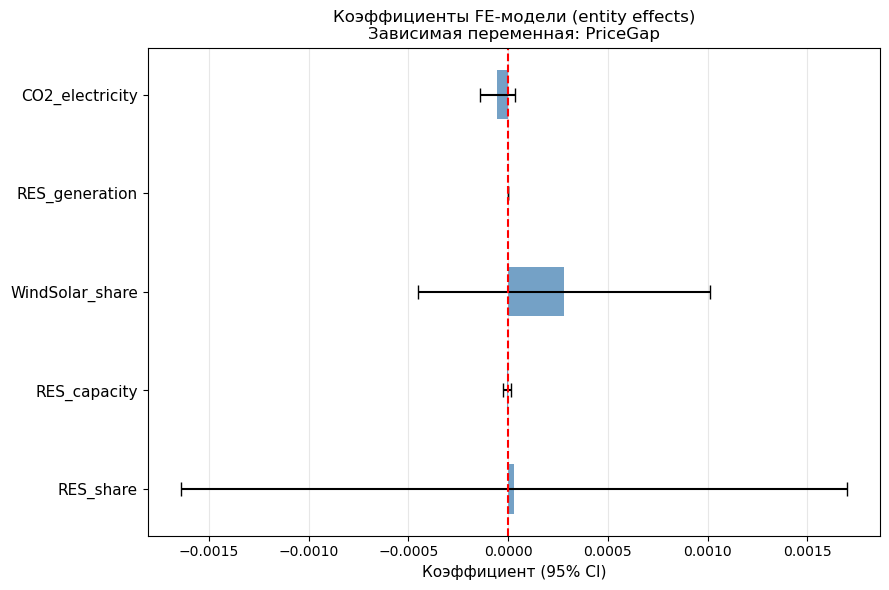

✓ coefplot.png сохранён


In [22]:
#20
coef_plot_vars = [v for v in SPEC_VARS if v in fe_result.params.index]
coefs  = fe_result.params[coef_plot_vars]
se     = fe_result.std_errors[coef_plot_vars]
ci_low = coefs - 1.96 * se
ci_hi  = coefs + 1.96 * se

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_plot_vars) * 1.2)))

y_pos = range(len(coef_plot_vars))
ax.barh(y_pos, coefs, xerr=1.96 * se, color='steelblue',
        error_kw=dict(ecolor='black', capsize=5), alpha=0.75, height=0.5)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(coef_plot_vars, fontsize=11)
ax.set_xlabel('Коэффициент (95% CI)', fontsize=11)
ax.set_title('Коэффициенты FE-модели (entity effects)\nЗависимая переменная: PriceGap',
             fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('coefplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ coefplot.png сохранён")


In [23]:

# ─────────────────────────────────────────────────────────────────────────────
# ШАГ 21. СПИСОК СОХРАНЁННЫХ ФАЙЛОВ
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("СПИСОК СОХРАНЁННЫХ ФАЙЛОВ")
print("=" * 60)

output_files = [
    ('missing_heatmap.png',           'Тепловая карта пропусков'),
    ('descriptive_stats.csv',         'Описательная статистика'),
    ('descriptive_by_country.csv',    'Описательная статистика по странам'),
    ('descriptive_by_year.csv',       'Описательная статистика по годам'),
    ('correlation_matrix.png',        'Матрица корреляций (график)'),
    ('correlation_matrix.csv',        'Матрица корреляций (таблица)'),
    ('trends_over_time.png',          'Динамика переменных по годам'),
    ('scatter_plots.png',             'Диаграммы рассеяния'),
    ('boxplot_country.png',           'Boxplot по странам'),
    ('boxplot_year.png',              'Boxplot по годам'),
    ('unit_root_results.csv',         'Тесты на единичный корень'),
    ('vif_results.csv',               'VIF — мультиколлинеарность'),
    ('ols_pooled_summary.txt',        'Результаты Pooled OLS'),
    ('fe_summary.txt',                'Результаты FE-модели'),
    ('re_summary.txt',                'Результаты RE-модели'),
    ('twoway_fe_summary.txt',         'Результаты двусторонней FE'),
    ('specifications_comparison.csv', 'Сравнение спецификаций'),
    ('residual_diagnostics.png',      'Диагностика остатков'),
    ('summary_table.csv',             'Итоговая сводная таблица'),
    ('coefplot.png',                  'График коэффициентов FE'),
]

for fname, descr in output_files:
    exists = '✓' if os.path.exists(fname) else '✗ не создан'
    print(f"  {exists}  {fname:42s}  {descr}")

print("\n✓ Анализ завершён.")



СПИСОК СОХРАНЁННЫХ ФАЙЛОВ
  ✓  missing_heatmap.png                         Тепловая карта пропусков
  ✓  descriptive_stats.csv                       Описательная статистика
  ✓  descriptive_by_country.csv                  Описательная статистика по странам
  ✓  descriptive_by_year.csv                     Описательная статистика по годам
  ✓  correlation_matrix.png                      Матрица корреляций (график)
  ✓  correlation_matrix.csv                      Матрица корреляций (таблица)
  ✓  trends_over_time.png                        Динамика переменных по годам
  ✓  scatter_plots.png                           Диаграммы рассеяния
  ✓  boxplot_country.png                         Boxplot по странам
  ✓  boxplot_year.png                            Boxplot по годам
  ✓  unit_root_results.csv                       Тесты на единичный корень
  ✓  vif_results.csv                             VIF — мультиколлинеарность
  ✓  ols_pooled_summary.txt                      Результаты Pooled OLS
  

In [26]:
from linearmodels.panel import RandomEffects

X = df_panel[['RES_share', 'WindSolar_share', 'RES_generation', 'CO2_electricity']].dropna()
Y = df_panel['PriceGap'].reindex(X.index)

re = RandomEffects(Y, X).fit(cov_type='robust')
print(re.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:               PriceGap   R-squared:                        0.2152
Estimator:              RandomEffects   R-squared (Between):              0.7627
No. Observations:                 458   R-squared (Within):               0.0829
Date:                Wed, Apr 29 2026   R-squared (Overall):              0.6570
Time:                        21:51:07   Log-likelihood                    1097.8
Cov. Estimator:                Robust                                           
                                        F-statistic:                      31.127
Entities:                          27   P-value                           0.0000
Avg Obs:                       16.963   Distribution:                   F(4,454)
Min Obs:                       16.000                                           
Max Obs:                       17.000   F-statistic (robust):             22.380
                            